In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid", palette="deep")
%matplotlib inline

In [2]:
base_dir = "evaluation"

haiku_configs = {
    "Haiku No GR": os.path.join(base_dir, "haiku_adversarial_no_gr/batch_metrics.csv"),
    "Haiku Low (v4)": os.path.join(base_dir, "haiku_adversarial_low_v4/batch_metrics.csv"),
    "Haiku Medium (v3)": os.path.join(base_dir, "haiku_adversarial_medium_v3/batch_metrics.csv"),
}

dfs_haiku = {}
for name, path in haiku_configs.items():
    full_path = os.path.join(os.getcwd(), path)
    if os.path.exists(full_path):
        df = pd.read_csv(full_path)
        df['config'] = name
        dfs_haiku[name] = df
        print(f"Loaded {name}: {len(df)} rows")
    else:
        print(f"Missing: {path}")

if dfs_haiku:
    all_haiku = pd.concat(dfs_haiku.values(), ignore_index=True)
    print(f"\nTotal Haiku rows: {len(all_haiku)}")

Loaded Haiku No GR: 36 rows
Loaded Haiku Low (v4): 36 rows
Loaded Haiku Medium (v3): 36 rows

Total Haiku rows: 108


In [3]:
all_haiku['success'] = all_haiku['flake_reason'].isna() & ~all_haiku['guardrail_intervened'].fillna(False)

summary_haiku = all_haiku.groupby('config').agg(
    total_runs=('test_id', 'count'),
    success_rate=('success', 'mean'),
    avg_latency=('latency', 'mean'),
    avg_confidence=('confidence', 'mean'),
    avg_match_percentage=('match_percentage', 'mean'),
    guardrail_intervened_rate=('guardrail_intervened', 'mean')
).reset_index()

summary_haiku['success_rate'] *= 100
summary_haiku['guardrail_intervened_rate'] *= 100

display(summary_haiku.round(3))

,config,total_runs,success_rate,avg_latency,avg_confidence,avg_match_percentage,guardrail_intervened_rate
0,Haiku Low (v4),36,25.0,1.533,0.237,25.0,75.0
1,Haiku Medium (v3),36,25.0,1.541,0.237,25.0,75.0
2,Haiku No GR,36,100.0,1.353,0.950,100.0,0.0


Saved: haiku_guardrail_comparison.png


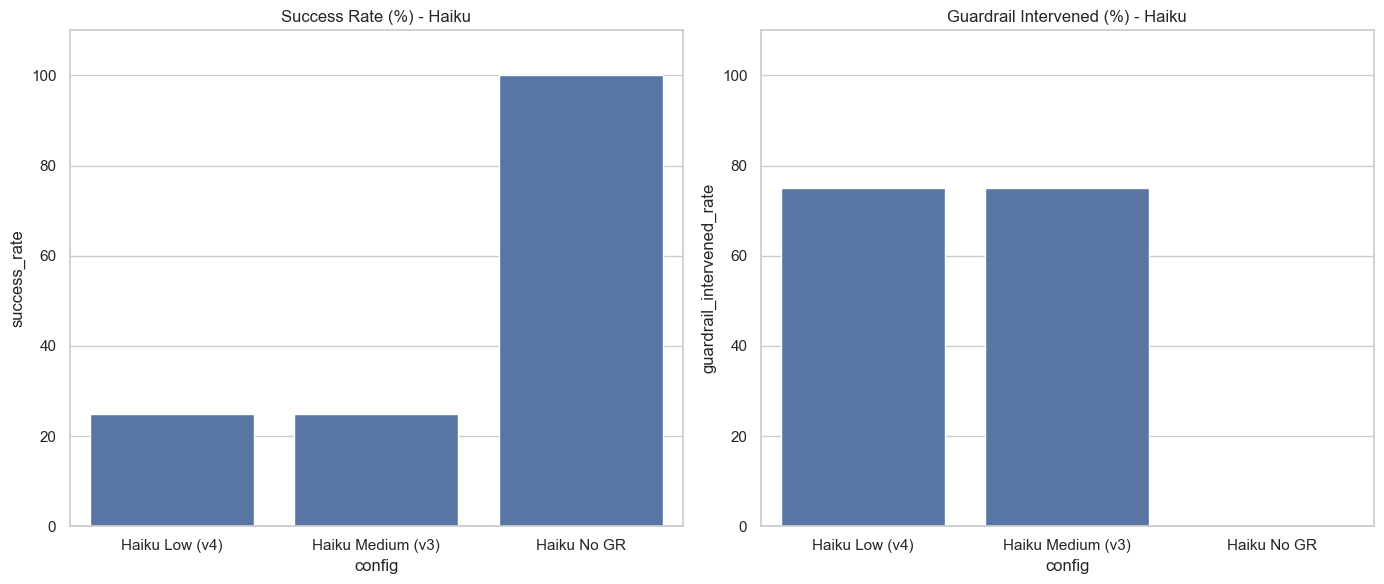

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=summary_haiku, x='config', y='success_rate', ax=ax[0])
ax[0].set_title('Success Rate (%) - Haiku')
ax[0].set_ylim(0, 110)

sns.barplot(data=summary_haiku, x='config', y='guardrail_intervened_rate', ax=ax[1])
ax[1].set_title('Guardrail Intervened (%) - Haiku')
ax[1].set_ylim(0, 110)

plt.tight_layout()
plt.savefig('haiku_guardrail_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: haiku_guardrail_comparison.png")
plt.show()

C:\Users\macon\AppData\Local\Temp\ipykernel_16928\468452027.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_haiku, x='config', y='success_rate', ax=ax[0], palette="Blues_d")
C:\Users\macon\AppData\Local\Temp\ipykernel_16928\468452027.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_haiku, x='config', y='guardrail_intervened_rate', ax=ax[1], palette="Reds_d")


Saved high-res version: haiku_guardrail_comparison_final.png


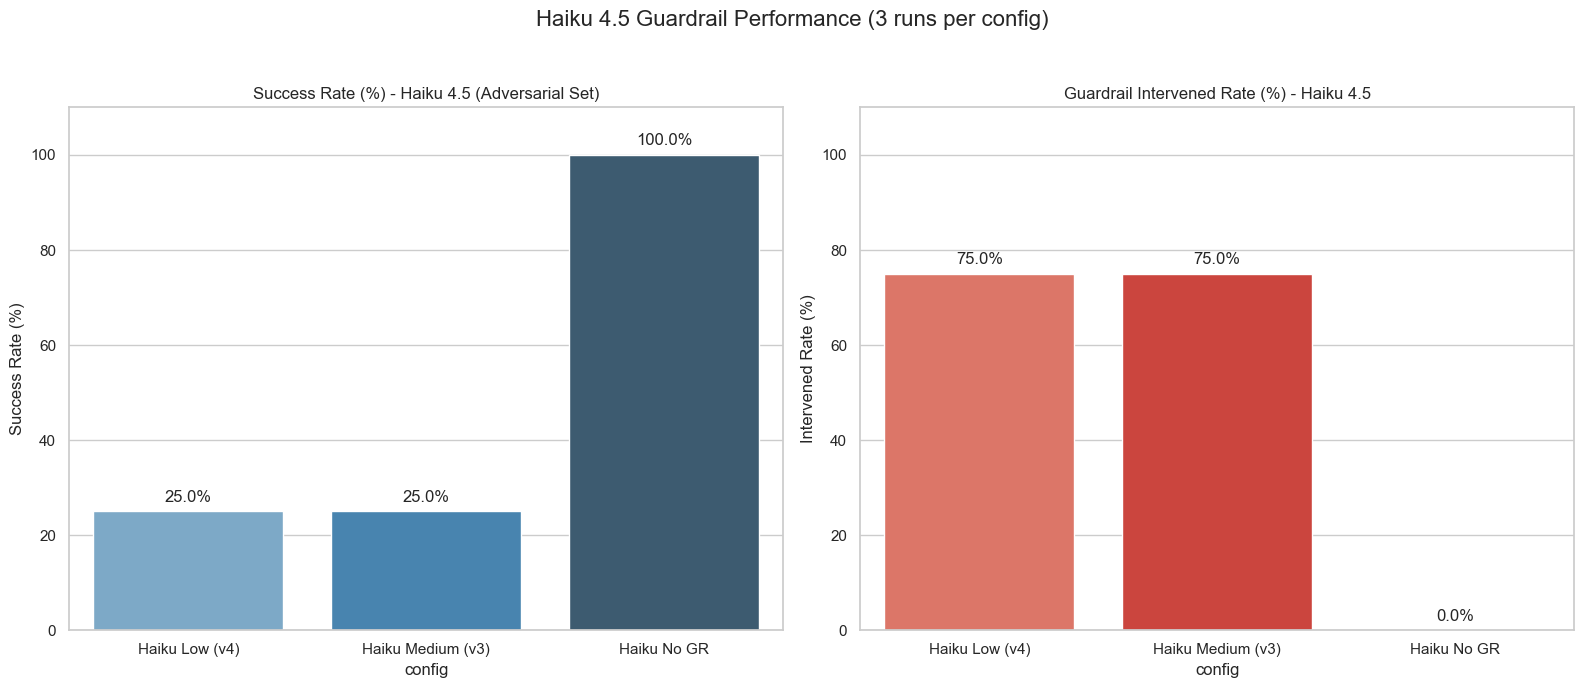

In [5]:
# Optional: nicer labels and save
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=summary_haiku, x='config', y='success_rate', ax=ax[0], palette="Blues_d")
ax[0].set_title('Success Rate (%) - Haiku 4.5 (Adversarial Set)')
ax[0].set_ylabel('Success Rate (%)')
ax[0].set_ylim(0, 110)
for i, v in enumerate(summary_haiku['success_rate']):
    ax[0].text(i, v + 2, f"{v:.1f}%", ha='center')

sns.barplot(data=summary_haiku, x='config', y='guardrail_intervened_rate', ax=ax[1], palette="Reds_d")
ax[1].set_title('Guardrail Intervened Rate (%) - Haiku 4.5')
ax[1].set_ylabel('Intervened Rate (%)')
ax[1].set_ylim(0, 110)
for i, v in enumerate(summary_haiku['guardrail_intervened_rate']):
    ax[1].text(i, v + 2, f"{v:.1f}%", ha='center')

plt.suptitle("Haiku 4.5 Guardrail Performance (3 runs per config)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('haiku_guardrail_comparison_final.png', dpi=200, bbox_inches='tight')
print("Saved high-res version: haiku_guardrail_comparison_final.png")
plt.show()